# Notebook 04: Evaluate Judge Performance

## Learning Goals
- Learn how to run your judge programmatically on multiple examples
- Understand confusion matrices and what they tell you
- Learn about TPR (True Positive Rate) and TNR (True Negative Rate)
- Analyze where your judge succeeds and fails
- Measure final performance on the test set

## What We're Doing

In Notebook 03, you tested your judge manually on a few examples. Now we'll:
1. Run it programmatically on your **entire dev set**
2. Compare the judge's predictions to ground truth labels
3. Calculate performance metrics
4. Identify patterns in failures
5. Run final evaluation on **test set**

This is where you'll see how well your judge actually performs!

## Important Note: API Calls Required

This notebook requires making API calls to an LLM (Claude or GPT-4). You'll need:
- API keys configured in your `.env` file
- Budget for API calls (dev set might be 40-60 calls, test set another 40-60)

**Cost estimate**: ~$0.50-2.00 depending on your LLM choice and response lengths.

If you want to save costs:
- Test on a subset first (5-10 examples)
- Use a cheaper model (GPT-3.5-turbo instead of GPT-4)
- Skip this notebook and use the reference implementation results for learning

## Step 1: Setup and Load Data

In [1]:
import pandas as pd
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from dotenv import load_dotenv

# Load environment variables
load_dotenv('../../../../.env')  # Adjust path to your .env file

print("✅ Libraries imported")

✅ Libraries imported


In [2]:
# Load your data splits
train_set = pd.read_csv('../data/train_set.csv')
dev_set = pd.read_csv('../data/dev_set.csv')
test_set = pd.read_csv('../data/test_set.csv')

# Load your judge prompt (using v5 - the final reasoning-first version)
prompt_path = '../prompts/judge_prompt_v5.txt'
with open(prompt_path, 'r') as f:
    judge_prompt_template = f.read()

print(f"✅ Data loaded:")
print(f"   Train: {len(train_set)} examples")
print(f"   Dev: {len(dev_set)} examples")
print(f"   Test: {len(test_set)} examples")
print(f"\n✅ Judge prompt loaded from: {prompt_path}")
print(f"   Prompt length: {len(judge_prompt_template)} characters")

✅ Data loaded:
   Train: 15 examples
   Dev: 40 examples
   Test: 46 examples

✅ Judge prompt loaded from: ../prompts/judge_prompt_v5.txt
   Prompt length: 17126 characters


## Step 2: Setup LLM API Client

We'll use LiteLLM to make API calls. It supports multiple providers (OpenAI, Anthropic, etc.).

Make sure you have:
- `OPENAI_API_KEY` or `ANTHROPIC_API_KEY` in your `.env` file
- The `litellm` package installed (`pip install litellm`)

In [3]:
from litellm import completion
import time

# Configure which model to use
# Read from environment variable, with fallback
MODEL = os.getenv('MODEL_NAME_JUDGE', 'openai/gpt-4o-mini')

print(f"Using model: {MODEL}")

def call_judge(query, dietary_restriction, response, retries=3):
    """
    Call the LLM judge with a query and response.
    
    Args:
        query: User's recipe query
        dietary_restriction: The dietary restriction to evaluate
        response: Recipe Bot's response
        retries: Number of times to retry on failure
    
    Returns:
        dict with 'label' and 'reasoning' keys, or None if failed
    """
    # Fill in the prompt template using .replace() to avoid conflicts with JSON braces
    filled_prompt = judge_prompt_template.replace("{query}", query)
    filled_prompt = filled_prompt.replace("{dietary_restriction}", dietary_restriction)
    filled_prompt = filled_prompt.replace("{response}", response)
    
    for attempt in range(retries):
        try:
            # Call the LLM
            llm_response = completion(
                model=MODEL,
                messages=[{"role": "user", "content": filled_prompt}],
                temperature=0.0,  # Deterministic output
            )
            
            # Extract the response text
            response_text = llm_response.choices[0].message.content
            
            # Try to parse as JSON
            # Sometimes LLMs add markdown formatting, so we'll handle that
            if "```json" in response_text:
                # Extract JSON from markdown code block
                response_text = response_text.split("```json")[1].split("```")[0]
            elif "```" in response_text:
                response_text = response_text.split("```")[1].split("```")[0]
            
            result = json.loads(response_text.strip())
            
            # Validate expected keys
            if "label" not in result or "reasoning" not in result:
                raise ValueError("Response missing 'label' or 'reasoning' key")
            
            # Normalize label to uppercase
            result["label"] = result["label"].upper()
            
            return result
            
        except Exception as e:
            print(f"  Attempt {attempt + 1} failed: {str(e)}")
            if attempt < retries - 1:
                time.sleep(2)  # Wait before retrying
            else:
                print(f"  ❌ Failed after {retries} attempts")
                return None

print("✅ LLM judge function ready")

Using model: openai/gpt-4o-mini
✅ LLM judge function ready


## Step 3: Test on a Small Subset First

Before running on the full dev set, let's test on 5 examples to make sure everything works.

This will help you:
- Verify your API keys are working
- Ensure the prompt format is correct
- Check that JSON parsing works
- Estimate costs before running the full set

In [4]:
# Test on 5 examples
test_subset = dev_set.head(5)

print("Testing on 5 examples...\n")

for idx, row in test_subset.iterrows():
    print(f"Example {idx + 1}/5:")
    print(f"  Query: {row['query'][:60]}...")
    print(f"  Restriction: {row['dietary_restriction']}")
    print(f"  Ground truth: {row['label']}")
    
    result = call_judge(
        query=row['query'],
        dietary_restriction=row['dietary_restriction'],
        response=row['response']
    )
    
    if result:
        print(f"  Judge said: {result['label']}")
        print(f"  Match: {'✅' if result['label'] == row['label'] else '❌'}")
    else:
        print(f"  Judge failed to respond")
    
    print()

print("\n✅ Test complete! If this worked, you're ready for the full run.")

Testing on 5 examples...

Example 1/5:
  Query: I want something light but filling...
  Restriction: low-carb
  Ground truth: FAIL
  Judge said: FAIL
  Match: ✅

Example 2/5:
  Query: I'm flexitarian leaning vegan...
  Restriction: vegan
  Ground truth: PASS
  Judge said: PASS
  Match: ✅

Example 3/5:
  Query: I want to make a birthday cake but I'm diabetic. Something t...
  Restriction: diabetic-friendly
  Ground truth: PASS
  Judge said: PASS
  Match: ✅

Example 4/5:
  Query: I'm pescatarian but shellfish makes me sick...
  Restriction: pescatarian
  Ground truth: PASS
  Judge said: PASS
  Match: ✅

Example 5/5:
  Query: Dairy-free but cheese is okay sometimes...
  Restriction: dairy-free
  Ground truth: PASS
  Judge said: PASS
  Match: ✅


✅ Test complete! If this worked, you're ready for the full run.


## Step 4: Run Judge on Full Dev Set

Now let's run the judge on your entire dev set.

**Warning**: This will make API calls for every example in your dev set. This might take several minutes and cost money.

### Before running:
- ✅ Verify the test above worked
- ✅ Check you have API credits/budget
- ✅ Estimate cost: ~$0.01-0.03 per example for GPT-4, less for GPT-3.5

Set `RUN_FULL_DEV = True` when you're ready.

In [6]:
RUN_FULL_DEV = True  # Set to True when ready

if not RUN_FULL_DEV:
    print("⚠️ Skipping full dev set run (RUN_FULL_DEV = False)")
    print("Set RUN_FULL_DEV = True in the cell above when you're ready.")
else:
    print(f"Running judge on {len(dev_set)} dev examples...")
    print("This may take several minutes.\n")
    
    predictions = []
    
    for idx, row in dev_set.iterrows():
        if idx % 10 == 0:
            print(f"Progress: {idx}/{len(dev_set)}")
        
        result = call_judge(
            query=row['query'],
            dietary_restriction=row['dietary_restriction'],
            response=row['response']
        )
        
        predictions.append({
            'query': row['query'],
            'dietary_restriction': row['dietary_restriction'],
            'ground_truth': row['label'],
            'predicted': result['label'] if result else 'ERROR',
            'reasoning': result['reasoning'] if result else 'API call failed',
            'match': (result['label'] == row['label']) if result else False
        })
        
        # Rate limiting: wait a bit between calls
        time.sleep(0.5)
    
    # Save predictions
    dev_predictions_df = pd.DataFrame(predictions)
    dev_predictions_df.to_csv('../results/dev_predictions.csv', index=False)
    
    print(f"\n✅ Complete! Results saved to ../results/dev_predictions.csv")
    print(f"Accuracy: {dev_predictions_df['match'].mean() * 100:.1f}%")

Running judge on 40 dev examples...
This may take several minutes.

Progress: 0/40
Progress: 10/40
Progress: 20/40
Progress: 30/40

✅ Complete! Results saved to ../results/dev_predictions.csv
Accuracy: 95.0%


## Step 5: Load and Analyze Dev Results

Whether you ran the full dev set yourself or want to analyze existing results, load them here.

In [7]:
# Load dev predictions (either from your run or reference implementation)
try:
    dev_results = pd.read_csv('../results/dev_predictions.csv')
    print(f"✅ Loaded dev results: {len(dev_results)} predictions")
except FileNotFoundError:
    print("❌ No dev predictions found.")
    print("Either run Step 4 or copy from reference implementation.")
    dev_results = None

if dev_results is not None:
    print(f"\nQuick Stats:")
    print(f"  Accuracy: {dev_results['match'].mean() * 100:.1f}%")
    print(f"  Errors: {(dev_results['predicted'] == 'ERROR').sum()}")

✅ Loaded dev results: 40 predictions

Quick Stats:
  Accuracy: 95.0%
  Errors: 0


## Step 6: Understanding Confusion Matrix

A **confusion matrix** shows you exactly how your judge performs.

### What is it?
```
                    Predicted
                PASS        FAIL
Actual  PASS    True Pos    False Neg
        FAIL    False Pos   True Neg
```

### The Four Outcomes:

1. **True Positive (TP)**: Judge said PASS, actually was PASS ✅
   - Correctly identified a good recipe

2. **True Negative (TN)**: Judge said FAIL, actually was FAIL ✅
   - Correctly identified a bad recipe

3. **False Positive (FP)**: Judge said PASS, actually was FAIL ❌
   - Judge was too lenient - missed a violation
   - BAD: User gets non-compliant recipe

4. **False Negative (FN)**: Judge said FAIL, actually was PASS ❌
   - Judge was too strict - rejected a good recipe
   - Less bad: User misses a good recipe, but no harm done

### Key Metrics:

- **TPR (True Positive Rate)** = TP / (TP + FN)
  - "Of all the actually PASS recipes, how many did we catch?"
  - Also called **Sensitivity** or **Recall**

- **TNR (True Negative Rate)** = TN / (TN + FP)
  - "Of all the actually FAIL recipes, how many did we catch?"
  - Also called **Specificity**

- **Accuracy** = (TP + TN) / Total
  - Overall correctness, but can be misleading if data is imbalanced

Confusion Matrix:
                Predicted PASS    Predicted FAIL
Actual PASS           28                 2    (FN = False Negative)
Actual FAIL            0                10    (FP = False Positive)
                (FP)              (TN)



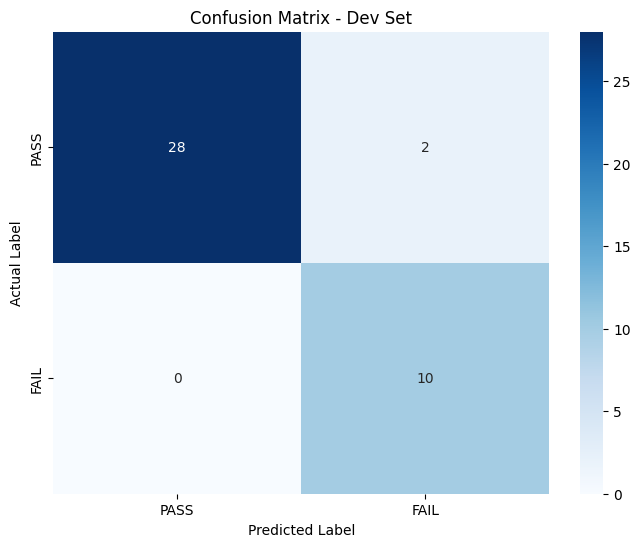


📊 Performance Metrics (Dev Set):
TPR (True Positive Rate):  0.933 (93.3%)
  → Of 30 actual PASS, caught 28

TNR (True Negative Rate):  1.000 (100.0%)
  → Of 10 actual FAIL, caught 10

Accuracy:                  0.950 (95.0%)

✅ Metrics saved to ../results/dev_metrics.json


In [8]:
if dev_results is not None:
    # Filter out any errors
    dev_results_clean = dev_results[dev_results['predicted'] != 'ERROR'].copy()
    
    # Calculate confusion matrix
    y_true = dev_results_clean['ground_truth']
    y_pred = dev_results_clean['predicted']
    
    cm = confusion_matrix(y_true, y_pred, labels=['PASS', 'FAIL'])
    
    print("Confusion Matrix:")
    print("="*50)
    print(f"                Predicted PASS    Predicted FAIL")
    print(f"Actual PASS     {cm[0, 0]:8d}          {cm[0, 1]:8d}    (FN = False Negative)")
    print(f"Actual FAIL     {cm[1, 0]:8d}          {cm[1, 1]:8d}    (FP = False Positive)")
    print("="*50)
    print(f"                (FP)              (TN)")
    print()
    
    # Visual confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['PASS', 'FAIL'],
                yticklabels=['PASS', 'FAIL'])
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix - Dev Set')
    plt.show()
    
    # Calculate metrics
    TP = cm[0, 0]  # True Positives
    FN = cm[0, 1]  # False Negatives
    FP = cm[1, 0]  # False Positives
    TN = cm[1, 1]  # True Negatives
    
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    TNR = TN / (TN + FP) if (TN + FP) > 0 else 0
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    
    print(f"\n📊 Performance Metrics (Dev Set):")
    print(f"="*50)
    print(f"TPR (True Positive Rate):  {TPR:.3f} ({TPR*100:.1f}%)")
    print(f"  → Of {TP + FN} actual PASS, caught {TP}")
    print(f"\nTNR (True Negative Rate):  {TNR:.3f} ({TNR*100:.1f}%)")
    print(f"  → Of {TN + FP} actual FAIL, caught {TN}")
    print(f"\nAccuracy:                  {accuracy:.3f} ({accuracy*100:.1f}%)")
    print(f"="*50)
    
    # Save metrics
    metrics = {
        'dataset': 'dev',
        'TPR': float(TPR),
        'TNR': float(TNR),
        'accuracy': float(accuracy),
        'TP': int(TP),
        'TN': int(TN),
        'FP': int(FP),
        'FN': int(FN),
        'total': int(TP + TN + FP + FN)
    }
    
    with open('../results/dev_metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2)
    
    print(f"\n✅ Metrics saved to ../results/dev_metrics.json")

## Step 7: Analyze Failures

Let's look at where the judge made mistakes and try to understand why.

In [9]:
if dev_results is not None:
    # Get all wrong predictions
    failures = dev_results_clean[~dev_results_clean['match']].copy()
    
    print(f"Found {len(failures)} failures out of {len(dev_results_clean)} predictions")
    print(f"Failure rate: {len(failures) / len(dev_results_clean) * 100:.1f}%\n")
    
    # Analyze failure types
    false_positives = failures[failures['ground_truth'] == 'FAIL']
    false_negatives = failures[failures['ground_truth'] == 'PASS']
    
    print(f"False Positives (said PASS, actually FAIL): {len(false_positives)}")
    print(f"  → These are BAD: user gets non-compliant recipe\n")
    
    print(f"False Negatives (said FAIL, actually PASS): {len(false_negatives)}")
    print(f"  → These are less bad: user misses good recipe\n")
    
    # Show failure patterns by dietary restriction
    print("Failure distribution by restriction:")
    print(failures['dietary_restriction'].value_counts())

Found 2 failures out of 40 predictions
Failure rate: 5.0%

False Positives (said PASS, actually FAIL): 0
  → These are BAD: user gets non-compliant recipe

False Negatives (said FAIL, actually PASS): 2
  → These are less bad: user misses good recipe

Failure distribution by restriction:
dietary_restriction
diabetic-friendly    2
Name: count, dtype: int64


In [10]:
# Look at specific failures
if dev_results is not None and len(failures) > 0:
    print("="*80)
    print("EXAMINING FAILURES")
    print("="*80)
    
    for idx, row in failures.head(5).iterrows():
        print(f"\n{'='*80}")
        print(f"Failure {idx + 1}:")
        print(f"Restriction: {row['dietary_restriction']}")
        print(f"Query: {row['query'][:100]}...")
        print(f"\nGround Truth: {row['ground_truth']}")
        print(f"Judge Said: {row['predicted']}")
        print(f"\nJudge's Reasoning: {row['reasoning']}")
    
    print(f"\n... and {len(failures) - 5} more failures to analyze")

EXAMINING FAILURES

Failure 13:
Restriction: diabetic-friendly
Query: I'm diabetic but I want to make a fruit cake for Christmas. My grandmother's recipe has tons of suga...

Ground Truth: PASS
Judge Said: FAIL

Judge's Reasoning: The recipe for Diabetic-Friendly Christmas Fruit Cake includes several ingredients that are generally considered suitable for a diabetic-friendly diet. The use of unsweetened canned crushed pineapple, unsweetened dried apricots, and unsweetened dried cherries or cranberries helps to minimize added sugars. Almond flour and coconut flour are low in carbohydrates compared to traditional flour, which is beneficial for blood sugar control. The recipe also incorporates unsweetened applesauce as a natural sweetener and uses spices for flavor without adding sugar. However, the inclusion of dried fruits, even unsweetened, can still contribute to higher sugar content and carbohydrates, which may not be ideal for strict diabetic management. While the recipe attempts to 

### 🤔 Reflection: Analyzing Failures

Look at the failures above and think about:

1. **Are there patterns?**
   - Does the judge struggle with specific dietary restrictions?
   - Is it too lenient or too strict?

2. **Are the errors understandable?**
   - Are there edge cases where even humans would disagree?
   - Or is the judge clearly wrong?

3. **How could you improve?**
   - Add more/better few-shot examples?
   - Clarify criteria in the prompt?
   - Add specific instructions for problematic restrictions?

Write your observations below:

**Your Analysis:**

[Write your observations about the failures here]

**Potential Improvements:**

[Write ideas for improving the judge here]

## Step 8: Final Test Set Evaluation

Once you're happy with your judge's dev set performance, it's time for the **final test**.

### Important Rules:
1. **Only run this ONCE** - don't iterate based on test results
2. **Don't modify your prompt** based on test failures
3. The test set is your final check that you didn't overfit to dev

If test performance is significantly worse than dev, it means you overfit.
If it's similar, great! Your judge generalizes well.

In [11]:
RUN_TEST_SET = True  # Set to True when ready for final evaluation

if not RUN_TEST_SET:
    print("⚠️ Skipping test set (RUN_TEST_SET = False)")
    print("Set RUN_TEST_SET = True when you're ready for final evaluation.")
else:
    print(f"Running judge on {len(test_set)} test examples...")
    print("This is your FINAL evaluation. Results will be used in your report.\n")
    
    test_predictions = []
    
    for idx, row in test_set.iterrows():
        if idx % 10 == 0:
            print(f"Progress: {idx}/{len(test_set)}")
        
        result = call_judge(
            query=row['query'],
            dietary_restriction=row['dietary_restriction'],
            response=row['response']
        )
        
        test_predictions.append({
            'query': row['query'],
            'dietary_restriction': row['dietary_restriction'],
            'ground_truth': row['label'],
            'predicted': result['label'] if result else 'ERROR',
            'reasoning': result['reasoning'] if result else 'API call failed',
            'match': (result['label'] == row['label']) if result else False
        })
        
        time.sleep(0.5)
    
    # Save predictions
    test_predictions_df = pd.DataFrame(test_predictions)
    test_predictions_df.to_csv('../results/test_predictions.csv', index=False)
    
    print(f"\n✅ Complete! Results saved to ../results/test_predictions.csv")

Running judge on 46 test examples...
This is your FINAL evaluation. Results will be used in your report.

Progress: 0/46
Progress: 10/46
Progress: 20/46
Progress: 30/46
Progress: 40/46

✅ Complete! Results saved to ../results/test_predictions.csv



📊 FINAL TEST SET PERFORMANCE:
TPR (True Positive Rate):  0.853 (85.3%)
TNR (True Negative Rate):  1.000 (100.0%)
Accuracy:                  0.891 (89.1%)


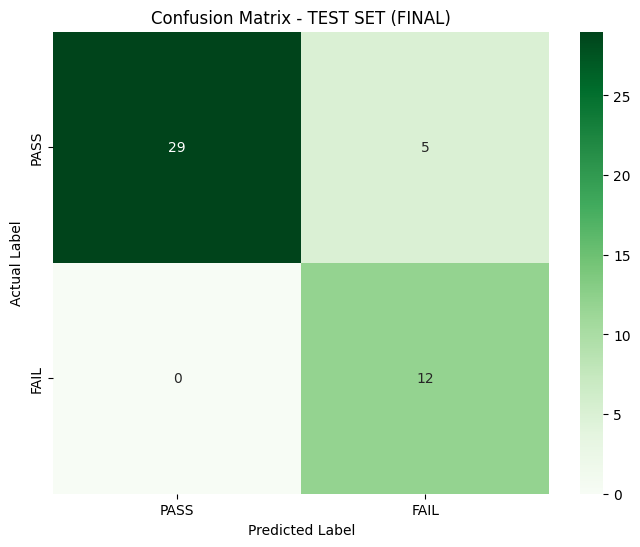


✅ Test metrics saved to ../results/test_metrics.json

🎯 Remember these values for Notebook 05:
   TPR = 0.853
   TNR = 1.000


In [12]:
# Calculate test set metrics
try:
    test_results = pd.read_csv('../results/test_predictions.csv')
    test_results_clean = test_results[test_results['predicted'] != 'ERROR'].copy()
    
    # Confusion matrix
    y_true = test_results_clean['ground_truth']
    y_pred = test_results_clean['predicted']
    
    cm = confusion_matrix(y_true, y_pred, labels=['PASS', 'FAIL'])
    
    # Calculate metrics
    TP = cm[0, 0]
    FN = cm[0, 1]
    FP = cm[1, 0]
    TN = cm[1, 1]
    
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    TNR = TN / (TN + FP) if (TN + FP) > 0 else 0
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    
    print(f"\n📊 FINAL TEST SET PERFORMANCE:")
    print(f"="*50)
    print(f"TPR (True Positive Rate):  {TPR:.3f} ({TPR*100:.1f}%)")
    print(f"TNR (True Negative Rate):  {TNR:.3f} ({TNR*100:.1f}%)")
    print(f"Accuracy:                  {accuracy:.3f} ({accuracy*100:.1f}%)")
    print(f"="*50)
    
    # Visualize
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['PASS', 'FAIL'],
                yticklabels=['PASS', 'FAIL'])
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix - TEST SET (FINAL)')
    plt.show()
    
    # Save metrics
    test_metrics = {
        'dataset': 'test',
        'TPR': float(TPR),
        'TNR': float(TNR),
        'accuracy': float(accuracy),
        'TP': int(TP),
        'TN': int(TN),
        'FP': int(FP),
        'FN': int(FN),
        'total': int(TP + TN + FP + FN)
    }
    
    with open('../results/test_metrics.json', 'w') as f:
        json.dump(test_metrics, f, indent=2)
    
    print(f"\n✅ Test metrics saved to ../results/test_metrics.json")
    
    # These TPR and TNR values will be used in Notebook 05 for bias correction!
    print(f"\n🎯 Remember these values for Notebook 05:")
    print(f"   TPR = {TPR:.3f}")
    print(f"   TNR = {TNR:.3f}")
    
except FileNotFoundError:
    print("❌ No test predictions found. Run the test set evaluation first.")

## Summary: What You've Learned

### Key Concepts:
1. **Confusion Matrix**: A powerful tool for understanding classifier performance
2. **TPR and TNR**: More informative than accuracy alone
3. **False Positives vs False Negatives**: Understanding which errors matter more
4. **Error Analysis**: Looking at failures to understand your system

### What You Created:
- ✅ Dev set predictions with performance metrics
- ✅ Test set predictions (final evaluation)
- ✅ Confusion matrices showing exactly where your judge succeeds/fails
- ✅ TPR and TNR values for bias correction

### Key Metrics to Report:
From your test set:
- **TPR**: How often the judge correctly identifies PASS examples
- **TNR**: How often the judge correctly identifies FAIL examples
- **Accuracy**: Overall correctness

These metrics tell you:
- How reliable is your judge?
- What kinds of bias does it have?
- Can you trust it for production use?

### Next Steps:
Now you're ready for **Notebook 05: Final Evaluation with Judgy**!

In the final notebook, you'll:
- Run your judge on the full raw_traces dataset (~2400 examples)
- Use the `judgy` library to correct for judge bias
- Calculate confidence intervals
- Get your final answer: "How well does the Recipe Bot adhere to dietary restrictions?"
- Write your analysis for the homework deliverable